In [8]:
import pandas as pd
import requests
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar los datos (puedes usar la URL directa o el archivo local)
url = "https://catalogodatos.cnmc.es/dataset/8a2461de-07b9-4bbc-9e56-db06270f888a/resource/e63f5db2-0433-4b72-8647-e5a4c74f1876/download/ds_14042_1.json"
response = requests.get(url)

# FORZAMOS LA CODIFICACIÓN PARA IGNORAR EL BOM
response.encoding = 'utf-8-sig'
data = response.json()
df = pd.DataFrame(data)


# 2. Limpieza básica (asegurar que el precio es numérico)
df['promedio_de_pvp_diario_cubo'] = pd.to_numeric(df['promedio_de_pvp_diario_cubo'], errors='coerce')
df = df.dropna(subset=['promedio_de_pvp_diario_cubo'])

# 3. Agrupar por producto y extraer la lista de precios
# Esto crea el formato: { "Producto A": [1.2, 1.3...], "Producto B": [...] }
grouped_data = df.groupby('producto')['promedio_de_pvp_diario_cubo'].apply(list).to_dict()

# 4. Transformar al formato que espera una librería de React (como Victory o Plotly)
formatted_output = []
for producto, precios in grouped_data.items():
    formatted_output.append({
        "x": producto,
        "y": precios
    })


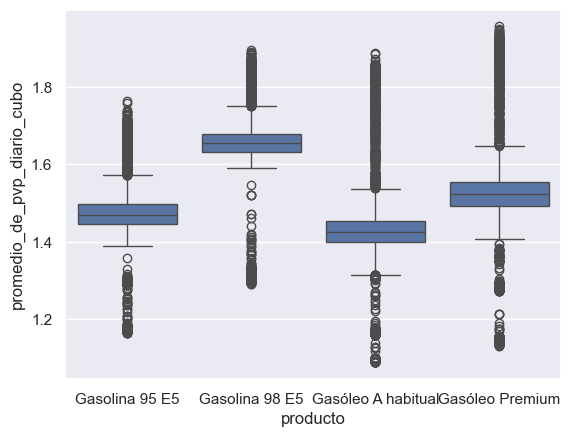

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
sns.boxplot(x=df["producto"], y=df["promedio_de_pvp_diario_cubo"])
plt.show()

In [9]:
# 1. Definir la ruta y el nombre del archivo
relative_path = os.path.join('..', 'src', 'assets', 'data')
file_name = 'boxplot_price_by_product_iran_war_2026.json'
full_path = os.path.join(relative_path, file_name)

with open(full_path, 'w', encoding='utf-8') as f:
    json.dump(
        formatted_output,            
        f, 
        ensure_ascii=False,    # Permite ver acentos como 'ó' en lugar de '\u00f3'
        indent=4,              # Crea saltos de línea y sangrías (legible)
        # sort_keys=True        
    )